In [1]:
import pandas as pd

file = "/g/data/gb02/mb0427/Australian_synoptic_weather_types/SWT_climatology/SWT_climatology_v20260129.csv"

df = pd.read_csv(file)

print(df.head())
print(df.columns)

         time assigned_SWT
0  1952-01-01         WH-A
1  1952-01-02         TH-A
2  1952-01-03         FH-A
3  1952-01-04        WCT-A
4  1952-01-05        WCT-A
Index(['time', 'assigned_SWT'], dtype='object')


In [2]:
import pandas as pd

file = "/g/data/gb02/mb0427/Australian_synoptic_weather_types/SWT_climatology/SWT_climatology_v20260129.csv"

df = pd.read_csv(file)

# convert date
df["time"] = pd.to_datetime(df["time"])

# cool season only
cool = df[df["time"].dt.month.isin([5,6,7,8,9,10])]

# select years
cool_1969 = cool[cool["time"].dt.year == 1969]
cool_2019 = cool[cool["time"].dt.year == 2019]

In [3]:
freq_1969 = cool_1969["assigned_SWT"].value_counts().sort_index()
freq_2019 = cool_2019["assigned_SWT"].value_counts().sort_index()

comparison = pd.concat(
    [freq_1969, freq_2019],
    axis=1
)

comparison.columns = ["1969", "2019"]

print(comparison)

              1969  2019
assigned_SWT            
CH-A            11  20.0
CH-B            10   2.0
COL-A            1   1.0
COL-B            6   2.0
COL-C            3   NaN
COL-D            5   NaN
COL-E            6   5.0
COL-F            7   6.0
EH-A             7  25.0
EH-C             7   9.0
EH-D             7   5.0
EH-E            13  15.0
FH-A             7   8.0
FH-B             5  10.0
FH-C             9   3.0
TH-A            17   4.0
TH-B             5  10.0
TH-C            11  13.0
WCT-A            9   2.0
WCT-B            7   3.0
WH-A             7   9.0
WH-B             8  12.0
WH-C             7  10.0
WH-D             9  10.0


In [4]:
pct_1969 = (
    cool_1969["assigned_SWT"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

pct_2019 = (
    cool_2019["assigned_SWT"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

comparison_pct = pd.concat(
    [pct_1969, pct_2019],
    axis=1
)

comparison_pct.columns = ["1969 (%)", "2019 (%)"]

print(comparison_pct.round(2))

              1969 (%)  2019 (%)
assigned_SWT                    
CH-A              5.98     10.87
CH-B              5.43      1.09
COL-A             0.54      0.54
COL-B             3.26      1.09
COL-C             1.63       NaN
COL-D             2.72       NaN
COL-E             3.26      2.72
COL-F             3.80      3.26
EH-A              3.80     13.59
EH-C              3.80      4.89
EH-D              3.80      2.72
EH-E              7.07      8.15
FH-A              3.80      4.35
FH-B              2.72      5.43
FH-C              4.89      1.63
TH-A              9.24      2.17
TH-B              2.72      5.43
TH-C              5.98      7.07
WCT-A             4.89      1.09
WCT-B             3.80      1.63
WH-A              3.80      4.89
WH-B              4.35      6.52
WH-C              3.80      5.43
WH-D              4.89      5.43


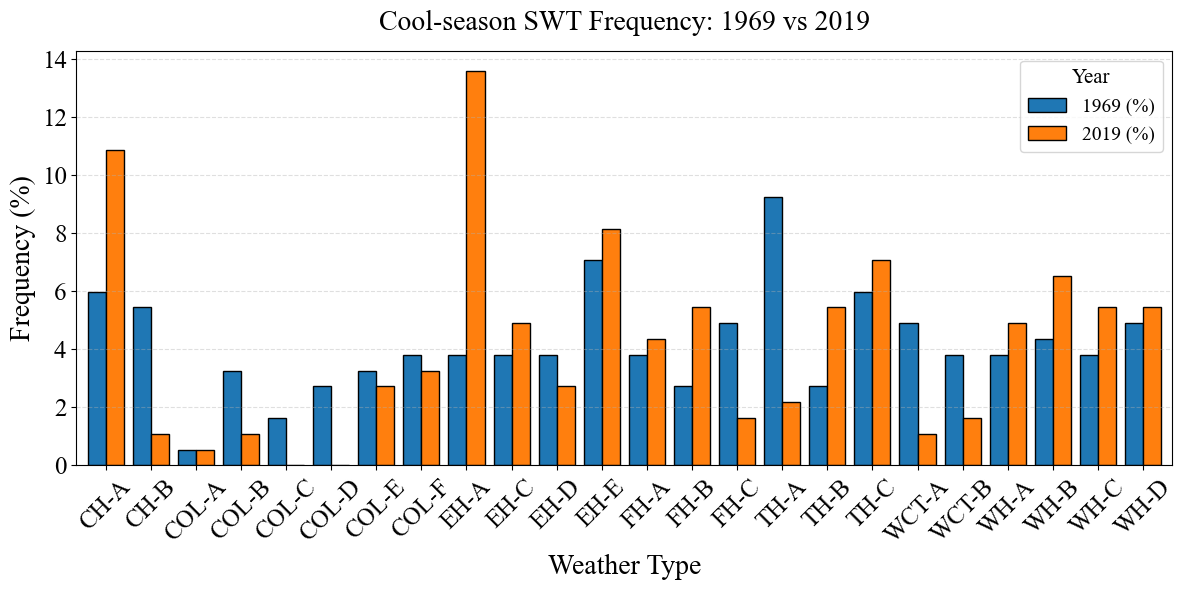

In [8]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# Times New Roman
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['mathtext.rm'] = 'Times New Roman'

ax = comparison_pct.plot(
    kind="bar",
    figsize=(12,6),
    width=0.8,
    edgecolor="black"
)

# Title
ax.set_title(
    "Cool-season SWT Frequency: 1969 vs 2019",
    fontsize=20,
    pad=15
)

# Axis labels
ax.set_xlabel(
    "Weather Type",
    fontsize=20
)

ax.set_ylabel(
    "Frequency (%)",
    fontsize=20
)

# Tick labels
ax.tick_params(
    axis='x',
    labelsize=18,
    rotation=45
)

ax.tick_params(
    axis='y',
    labelsize=18
)

# Legend
ax.legend(
    fontsize=14,
    title="Year",
    title_fontsize=15
)

# Optional grid
ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()